# Nested Groundwater Flow Models

This notebook shows how to build a nested model: a parent model with a child model
nested inside of it. The parent and child models are connected through a GWF-GWF
exchange.

First a single reference model is created. Then a nested model is created with a parent
and a child model. The results of the two are compared.

In [1]:
import os
import shutil

import matplotlib as mpl
import numpy as np
import pandas as pd
import xarray as xr

import nlmod

## 0. Configuration

Define a workspace for the models and the model grid properties.

In [2]:
# Define a workspace for the models
model_ws = "./model_comparison"

if os.path.exists(model_ws):
    shutil.rmtree(model_ws)
os.makedirs(model_ws, exist_ok=True)

In [3]:
# Define model grid properties
extent = [0, 10_000, 0, 10_000]
delr = 250.0
delc = 250.0
refine_child = 1  # refinement factor for child model
nlay = 3
botm = [-10, -20, -40]
ghb_head = 0.0  # head m+ref
ghb_resistance = 400.0  # days
well_q = -500.0  # Pumping rate m3/day

# some solver settings
ims_settings = {
    "outer_dvclose": 1e-9,
    "rcloserecord": "1e-6 strict",
    "linear_acceleration": "bicgstab",
}

# optional xt3d settings, do more harm than good in this example, but should be
# beneficial with significant refinement is performed.
xt3d_model = False
xt3d_exch = False

## 1. Create the single, uniform grid model

First, we create a single model that covers the whole extent. This will serve as a reference.

In [4]:
ds_single = nlmod.get_ds(
    extent,
    delr=delr,
    delc=delc,
    layer=nlay,
    botm=botm,
    model_name="single",
    model_ws=os.path.join(model_ws, "single"),
)
ds_single = nlmod.grid.refine(ds_single)
ds_single = nlmod.time.set_ds_time(
    ds_single, time=pd.Timestamp.today().normalize(), start=1
)

### Build the MODFLOW 6 simulation

In [5]:
# Create simulation and gwf model
sim_single = nlmod.sim.sim(ds_single)
tdis_single = nlmod.sim.tdis(ds_single, sim_single)
gwf_single = nlmod.gwf.gwf(ds_single, sim_single)
disv_single = nlmod.gwf.disv(ds_single, gwf_single)
ims_single = nlmod.sim.ims(sim_single, model=gwf_single, **ims_settings)
npf_single = nlmod.gwf.npf(
    ds_single, gwf_single, save_flows=True, xt3doptions=xt3d_model
)
ic_single = nlmod.gwf.ic(ds_single, gwf_single, starting_head=0.0)
oc_single = nlmod.gwf.oc(ds_single, gwf_single)

### Add boundary conditions

In [6]:
# Add GHB package to the top layer
ghb_cond = ds_single["area"] / ghb_resistance
ghb_single = nlmod.gwf.ghb(ds_single, gwf_single, bhead=ghb_head, cond=ghb_cond)

In [7]:
# Add a well in the center of the bottom layer
well_df = pd.DataFrame(
    {
        "x": [(extent[0] + extent[1]) / 2],
        "y": [(extent[2] + extent[3]) / 2],
        "Q": [well_q],
        "top": [botm[-2]],
        "botm": [botm[-1]],
    }
)
wel_single = nlmod.gwf.wells.wel_from_df(well_df, gwf_single)

Intersecting with grid: 100%|██████████| 1/1 [00:00<00:00, 385.51it/s]


### Write and run the single model

In [8]:
nlmod.sim.write_and_run(sim_single, ds_single, silent=True)

### Get output from the single model

In [9]:
head_single = nlmod.gwf.output.get_heads_da(ds=ds_single)

## 2. Create the nested parent-child model

Now, create a nested model with a parent model and a more refined child model in the center.

In [10]:
child_extent = [3750, 6250, 3750, 6250]

### Parent Model

The parent model covers the same extent as the single model, but is inactivated where
the child model will be.

In [11]:
ds_parent = nlmod.get_ds(
    extent,
    delr=delr,
    delc=delc,
    layer=nlay,
    botm=botm,
    model_name="parent",
    model_ws=os.path.join(model_ws, "nested"),
)
ds_parent = nlmod.grid.refine(ds_parent)
ds_parent = nlmod.time.set_ds_time(
    ds_parent, time=pd.Timestamp.today().normalize(), start=1
)

# deactivate parent cells that are within the child model extent
idomain = nlmod.grid.get_idomain(ds_parent)
inactive = (
    (ds_parent.x >= child_extent[0])
    & (ds_parent.x <= child_extent[1])
    & (ds_parent.y >= child_extent[2])
    & (ds_parent.y <= child_extent[3])
)
ds_parent["active_domain"] = xr.ones_like(ds_parent.layer, dtype=bool) * (~inactive)

#### Build the parent model simulation

In [12]:
sim_nested = nlmod.sim.sim(ds_parent)
tdis_nested = nlmod.sim.tdis(ds_parent, sim_nested)
gwf_parent = nlmod.gwf.gwf(ds_parent, sim_nested)
disv_parent = nlmod.gwf.disv(ds_parent, gwf_parent)
ims_nested = nlmod.sim.ims(sim_nested, **ims_settings)  # IMS for the whole simulation
npf_parent = nlmod.gwf.npf(
    ds_parent, gwf_parent, save_flows=True, xt3doptions=xt3d_model
)
ic_parent = nlmod.gwf.ic(ds_parent, gwf_parent, starting_head=0.0)
oc_parent = nlmod.gwf.oc(ds_parent, gwf_parent)

#### Add boundary conditions to the parent model

In [13]:
ghb_cond_parent = ds_parent["area"] / ghb_resistance
ghb_cond_parent = ghb_cond_parent.where(ds_parent["active_domain"].isel(layer=0), 0.0)
ghb_parent = nlmod.gwf.ghb(ds_parent, gwf_parent, bhead=ghb_head, cond=ghb_cond_parent)

### Child Model

The child model replaces the inactive zone in the parent model.

In [14]:
ds_child = nlmod.get_ds(
    child_extent,
    delr=delr / refine_child,
    delc=delc / refine_child,
    layer=nlay,
    botm=botm,
    model_name="child",
    model_ws=os.path.join(model_ws, "nested"),
)
ds_child = nlmod.grid.refine(ds_child)
ds_child = nlmod.time.set_ds_time(
    ds_child, time=pd.Timestamp.today().normalize(), start=1
)

#### Build the child model simulation

In [15]:
gwf_child = nlmod.gwf.gwf(ds_child, sim_nested)
disv_child = nlmod.gwf.disv(ds_child, gwf_child)
npf_child = nlmod.gwf.npf(ds_child, gwf_child, save_flows=True, xt3doptions=xt3d_model)
ic_child = nlmod.gwf.ic(ds_child, gwf_child, starting_head=0.0)
oc_child = nlmod.gwf.oc(ds_child, gwf_child)

#### Add boundary conditions to the child model

In [16]:
ghb_child = nlmod.gwf.ghb(
    ds_child,
    gwf_child,
    bhead=ghb_head * xr.ones_like(ds_child["top"]),
    cond=nlmod.grid.get_area(ds_child) / ghb_resistance,
)
wel_child = nlmod.gwf.wells.wel_from_df(well_df, gwf_child)

Intersecting with grid: 100%|██████████| 1/1 [00:00<00:00, 481.16it/s]


### GWF-GWF Exchange and run

In [17]:
gwfgwf = nlmod.sim.gwfgwf(sim_nested, ds_parent, ds_child, xt3d=xt3d_exch)

In [18]:
nlmod.sim.write_and_run(sim_nested, ds_parent, silent=True)

### Get output from the nested model

In [19]:
head_single = nlmod.gwf.output.get_heads_da(ds=ds_single)
head_parent = nlmod.gwf.output.get_heads_da(ds=ds_parent)
head_child = nlmod.gwf.output.get_heads_da(ds=ds_child)

## 3. Compare results

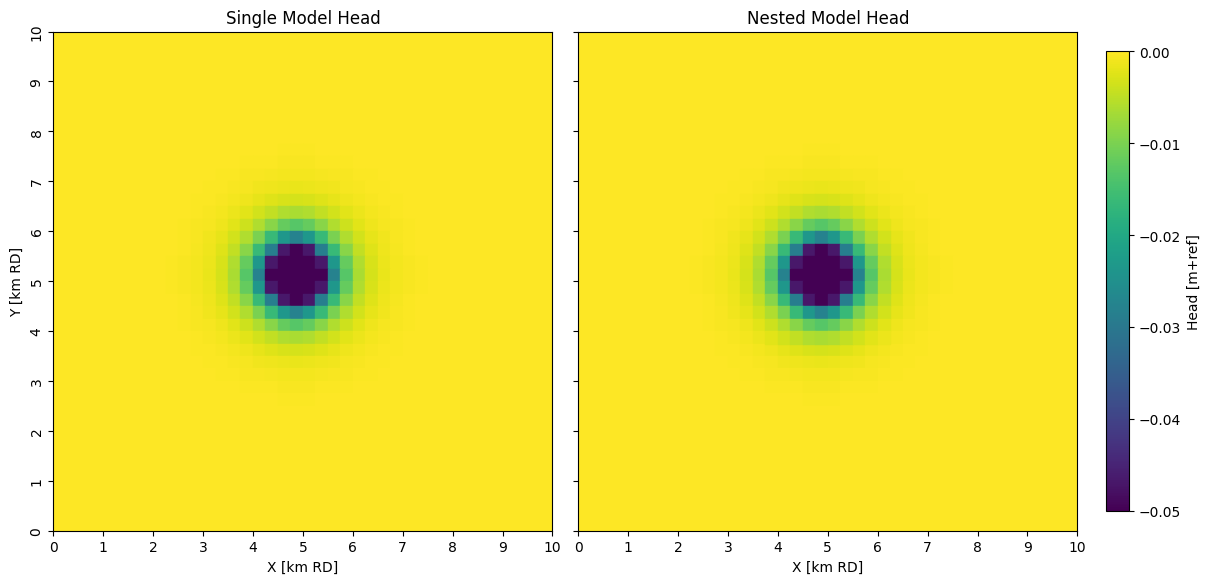

In [20]:
fig, (ax0, ax1) = nlmod.plot.get_map(
    nlmod.grid.get_extent(ds_single), nrows=1, ncols=2, figsize=(12, 6), sharey=True
)
vmin, vmax = -0.05, 0.0

nlmod.plot.map_array(
    head_single,
    ds_single,
    ax=ax0,
    vmin=vmin,
    vmax=vmax,
    plot_grid=False,
    colorbar=False,
)
ax0.set_title("Single Model Head")
nlmod.plot.map_array(
    head_parent,
    ds_parent,
    ax=ax1,
    vmin=vmin,
    vmax=vmax,
    plot_grid=False,
    colorbar_label="Head [m+ref]"
)
nlmod.plot.map_array(
    head_child, ds_child, ax=ax1, vmin=vmin, vmax=vmax, plot_grid=False, colorbar=False
)
ax1.set_title("Nested Model Head")
ax1.set_ylabel("");

### Plot the difference in heads

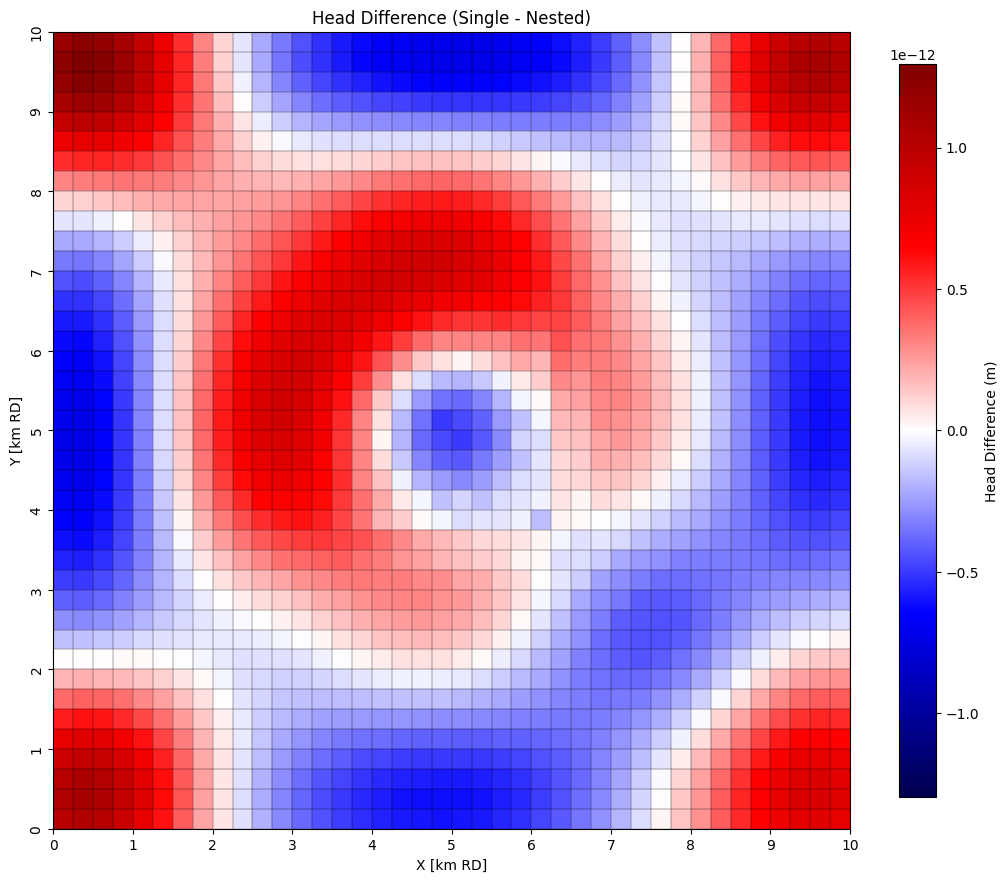

In [21]:
if (~ds_parent["active_domain"].isel(layer=0)).sum() == ds_child.sizes["icell2d"]:
    (icell2d,) = np.nonzero(~ds_parent["active_domain"].values[0])
    head_parent.values[:, :, icell2d] = head_child.values[0]
    dh = head_single - head_parent
    fig, ax = nlmod.plot.get_map(nlmod.grid.get_extent(ds_single))
    nlmod.plot.map_array(
        dh.isel(layer=0),
        ds_single,
        ax=ax,
        cmap="seismic",
        norm=mpl.colors.CenteredNorm(vcenter=0),
        colorbar_label="Head Difference (m)",
    )
    ax.set_title("Head Difference (Single - Nested)");

In [22]:
# cleanup model files
shutil.rmtree(model_ws)